# N577NA Flight Track Analysis
Parses the `gx:Track` KML, extracts lat/lon/altitude (EGM96, metres)/time, computes ground speed via Haversine and vertical speed, classifies climb/cruise/descent, and produces three figures.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from lxml import etree
from datetime import datetime, timezone
from scipy.stats import binned_statistic

KML_FILE = 'N577NA-track-EGM96.kml'

## 1  Parse KML

In [3]:
NS = {'kml': 'http://www.opengis.net/kml/2.2',
      'gx':  'http://www.google.com/kml/ext/2.2'}

tree  = etree.parse(KML_FILE)
track = tree.find('.//gx:Track', NS)

when_els  = track.findall('kml:when', NS)
coord_els = track.findall('gx:coord',  NS)

times  = [datetime.fromisoformat(e.text.rstrip('Z')).replace(tzinfo=timezone.utc)
          for e in when_els]
coords = [list(map(float, e.text.split())) for e in coord_els]   # lon lat alt_m

df = pd.DataFrame(coords, columns=['lon', 'lat', 'alt_m'])
df['time']   = times
df['t_s']    = (df['time'] - df['time'].iloc[0]).dt.total_seconds()
df['alt_ft'] = df['alt_m'] * 3.28084

# remove duplicate timestamps (GPS dropouts)
df = df.drop_duplicates(subset='t_s').reset_index(drop=True)

print(f"{len(df)} track points  |  "
      f"duration {df['t_s'].iloc[-1]/3600:.2f} h  |  "
      f"alt range {df['alt_ft'].min():.0f}–{df['alt_ft'].max():.0f} ft  |  "
      f"date {df['time'].iloc[0].strftime('%Y-%m-%d')}")

429 track points  |  duration 2.16 h  |  alt range 20016–30167 ft  |  date 2026-04-22


## 2  Compute ground speed (kts) and vertical speed (ft/min)

In [4]:
def haversine_m(lat1, lon1, lat2, lon2):
    """Great-circle distance in metres between consecutive track points."""
    R = 6_371_000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

lat = df['lat'].values;  lon = df['lon'].values
alt = df['alt_ft'].values;  t = df['t_s'].values

dt      = np.diff(t)                                   # seconds
dist_m  = haversine_m(lat[:-1], lon[:-1], lat[1:], lon[1:])
gs_kts  = dist_m / dt * 1.94384                        # knots
vs_fpm  = (np.diff(alt) / dt) * 60                     # ft/min
alt_mid = 0.5*(alt[:-1] + alt[1:])                     # mid-point altitude
t_mid   = 0.5*(t[:-1]   + t[1:])                       # mid-point time

# 5-point rolling median (pandas: NaN-safe)
gs_sm = pd.Series(gs_kts).rolling(5, center=True, min_periods=1).median().values
vs_sm = pd.Series(vs_fpm).rolling(5, center=True, min_periods=1).median().values

# ---- phase classification ----
VS_THRESH = 200   # ft/min
phase = np.where(vs_sm >  VS_THRESH, 'climb',
        np.where(vs_sm < -VS_THRESH, 'descent', 'cruise'))

df_seg = pd.DataFrame({'alt_mid': alt_mid, 't_mid_h': t_mid/3600,
                        'gs_kts':  gs_kts,  'gs_sm':  gs_sm,
                        'vs_fpm':  vs_fpm,  'vs_sm':  vs_sm,
                        'phase':   phase})
# sanity filter: keep realistic ground speeds
df_seg = df_seg[df_seg['gs_kts'].between(50, 700)].copy()

print(df_seg['phase'].value_counts())
for ph in ['cruise', 'climb', 'descent']:
    sub = df_seg[df_seg['phase'] == ph]
    if len(sub):
        print(f"  {ph:8s}: median GS {sub['gs_sm'].median():.1f} kts, "
              f"alt {sub['alt_mid'].min()/1000:.1f}–{sub['alt_mid'].max()/1000:.1f} kft, "
              f"median VS {sub['vs_sm'].median():.0f} ft/min")

phase
cruise    386
climb      42
Name: count, dtype: int64
  cruise  : median GS 459.0 kts, alt 29.8–30.2 kft, median VS 0 ft/min
  climb   : median GS 463.1 kts, alt 20.1–30.1 kft, median VS 2489 ft/min


## 3  Helper: binned-median profile

In [5]:
ALT_BINS = np.arange(18_000, 32_001, 1_000)   # 1 kft bins
COLORS   = {'climb': 'tomato', 'cruise': 'mediumseagreen', 'descent': 'goldenrod'}
MARKERS  = {'climb': 'o',      'cruise': 's',              'descent': '^'}

def binned_med(df_ph, y_col='gs_sm'):
    stat, edges, _ = binned_statistic(
        df_ph['alt_mid'], df_ph[y_col], statistic='median', bins=ALT_BINS)
    centers = 0.5*(edges[:-1] + edges[1:])
    mask = ~np.isnan(stat)
    return centers[mask]/1000, stat[mask]   # kft, values

## 4  Figure 1 – Flight profile (altitude & ground speed vs time)

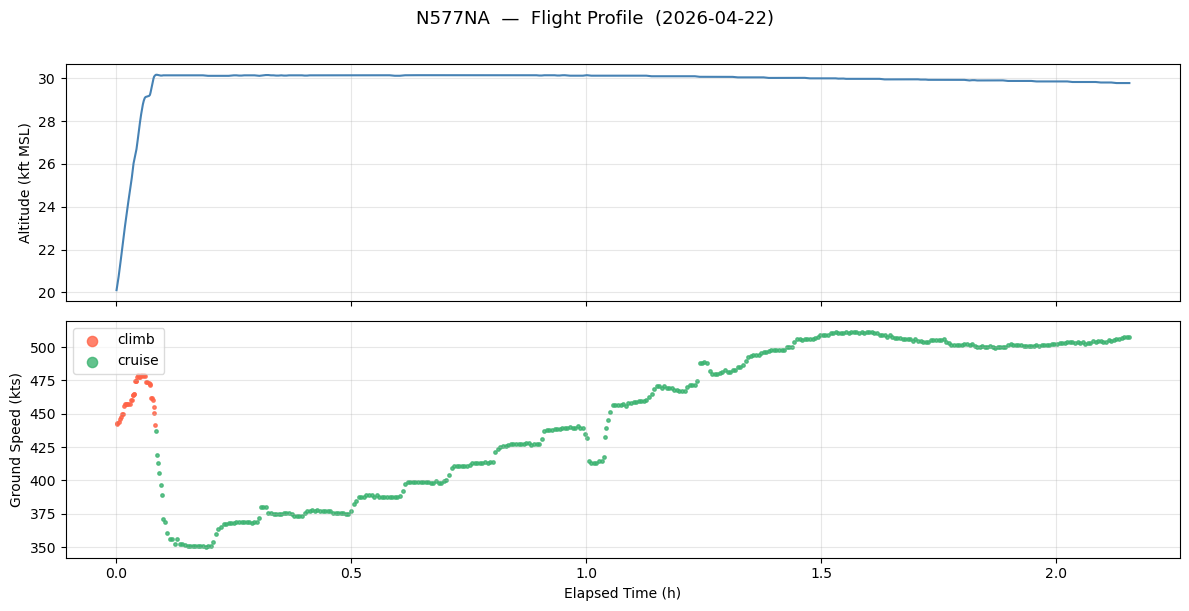

Saved N577NA_profile.png


In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle('N577NA  —  Flight Profile  (2026-04-22)', fontsize=13, y=1.01)

# altitude
ax1.plot(df_seg['t_mid_h'], df_seg['alt_mid']/1000,
         color='steelblue', lw=1.5)
ax1.set_ylabel('Altitude (kft MSL)')
ax1.grid(True, alpha=0.3)

# ground speed, coloured by phase
for ph, grp in df_seg.groupby('phase'):
    ax2.scatter(grp['t_mid_h'], grp['gs_sm'], s=6,
                color=COLORS[ph], label=ph, alpha=0.8)

ax2.set_ylabel('Ground Speed (kts)')
ax2.set_xlabel('Elapsed Time (h)')
ax2.legend(markerscale=3, framealpha=0.7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('N577NA_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved N577NA_profile.png')

## 5  Figure 2 – Ground speed vs altitude

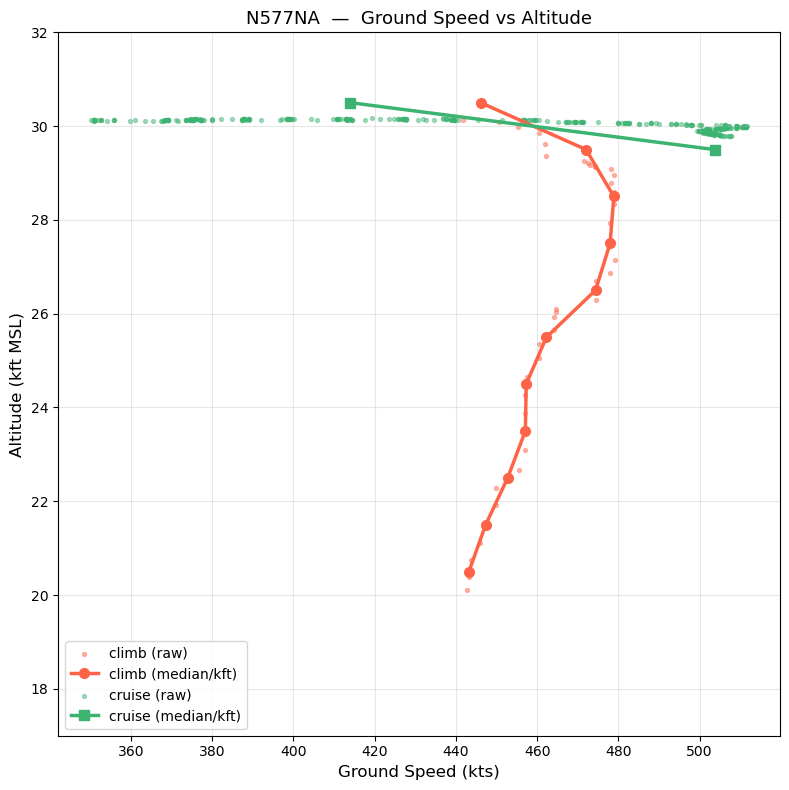

Saved N577NA_gs_vs_alt.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

for ph in ['climb', 'cruise', 'descent']:
    grp = df_seg[df_seg['phase'] == ph]
    if len(grp) == 0:
        continue
    ax.scatter(grp['gs_sm'], grp['alt_mid']/1000,
               s=8, alpha=0.45, color=COLORS[ph], label=f'{ph} (raw)')
    if len(grp) >= 5:
        alt_c, gs_med = binned_med(grp, 'gs_sm')
        ax.plot(gs_med, alt_c,
                color=COLORS[ph], lw=2.5,
                marker=MARKERS[ph], ms=7,
                label=f'{ph} (median/kft)')

ax.set_xlabel('Ground Speed (kts)', fontsize=12)
ax.set_ylabel('Altitude (kft MSL)', fontsize=12)
ax.set_title('N577NA  —  Ground Speed vs Altitude', fontsize=13)
ax.set_ylim(17, 32)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.legend(framealpha=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('N577NA_gs_vs_alt.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved N577NA_gs_vs_alt.png')

## 6  Figure 3 – Climb rate vs altitude

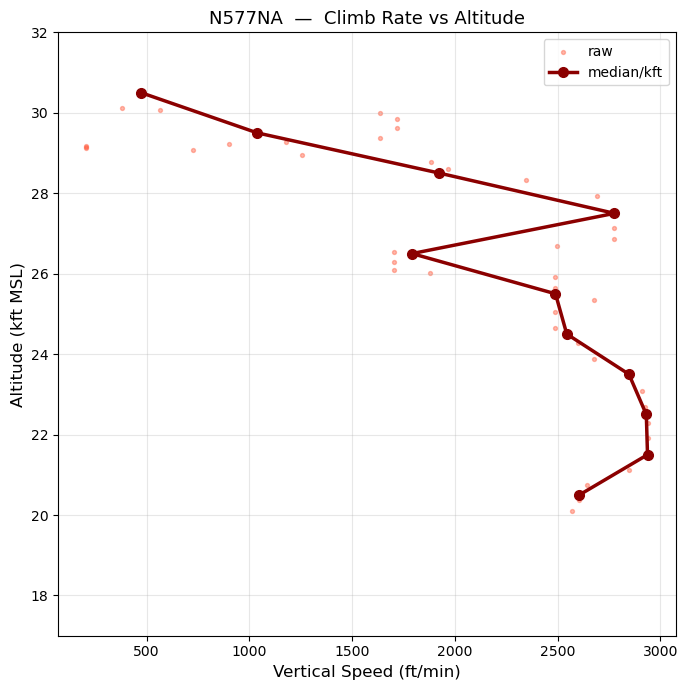

Saved N577NA_climb_rate_vs_alt.png


In [8]:
df_climb = df_seg[df_seg['phase'] == 'climb'].copy()

# clip extreme vertical-speed outliers for plotting
lo, hi = df_climb['vs_sm'].quantile([0.02, 0.98])
df_climb = df_climb[df_climb['vs_sm'].between(lo, hi)]

alt_c, vs_med = binned_med(df_climb, 'vs_sm')

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df_climb['vs_sm'], df_climb['alt_mid']/1000,
           s=8, alpha=0.45, color='tomato', label='raw')
ax.plot(vs_med, alt_c,
        color='darkred', lw=2.5, marker='o', ms=7, label='median/kft')

ax.set_xlabel('Vertical Speed (ft/min)', fontsize=12)
ax.set_ylabel('Altitude (kft MSL)', fontsize=12)
ax.set_title('N577NA  —  Climb Rate vs Altitude', fontsize=13)
ax.set_ylim(17, 32)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.legend(framealpha=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('N577NA_climb_rate_vs_alt.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved N577NA_climb_rate_vs_alt.png')

## 7  Summary statistics

In [9]:
cruise = df_seg[df_seg['phase'] == 'cruise']
climb  = df_seg[df_seg['phase'] == 'climb']

print('=== Cruise ===')
print(f"  Altitude range   : {cruise['alt_mid'].min()/1000:.1f}–{cruise['alt_mid'].max()/1000:.1f} kft")
print(f"  Ground speed     : {cruise['gs_sm'].median():.1f} kts median  "
      f"(IQR {cruise['gs_sm'].quantile(0.25):.1f}–{cruise['gs_sm'].quantile(0.75):.1f} kts)")

if len(climb):
    print('\n=== Climb (step-climbs) ===')
    print(f"  Altitude range   : {climb['alt_mid'].min()/1000:.1f}–{climb['alt_mid'].max()/1000:.1f} kft")
    print(f"  Ground speed     : {climb['gs_sm'].median():.1f} kts median")
    print(f"  Climb rate       : {climb['vs_sm'].median():.0f} ft/min median  "
          f"(max {climb['vs_sm'].max():.0f} ft/min)")

# ---- exported arrays ----
print('\n=== Arrays available ===')
print(f"  df        : {len(df)} rows — lat, lon, alt_m, alt_ft, time, t_s")
print(f"  df_seg    : {len(df_seg)} rows — alt_mid, gs_kts, gs_sm, vs_fpm, vs_sm, phase, t_mid_h")

=== Cruise ===
  Altitude range   : 29.8–30.2 kft
  Ground speed     : 459.0 kts median  (IQR 396.8–501.9 kts)

=== Climb (step-climbs) ===
  Altitude range   : 20.1–30.1 kft
  Ground speed     : 463.1 kts median
  Climb rate       : 2489 ft/min median  (max 2937 ft/min)

=== Arrays available ===
  df        : 429 rows — lat, lon, alt_m, alt_ft, time, t_s
  df_seg    : 428 rows — alt_mid, gs_kts, gs_sm, vs_fpm, vs_sm, phase, t_mid_h
